# Tracking infrastructure — PostgreSQL backend and S3 artifact store

This notebook trains nothing and writes nothing. It reads the experiment tracking setup and makes visible what would otherwise stay invisible: the fact that the MLflow runs live on remote infrastructure rather than on this machine.

## Why it exists

`mlflow ui` is a viewer. It shows the same screen whether it is reading a local `mlruns/` folder or a PostgreSQL database hosted elsewhere — same tables, same charts, nothing on screen naming the source. A screenshot of it proves nothing about where the runs actually live.

So instead of one screenshot, three views of the same runs, each reaching the database by its own route:

| View | Tool | Path to the data |
|---|---|---|
| **1 — this notebook** | Python | `mlflow` → `psycopg2` → Neon |
| 2 — Neon console | Browser | hosting provider console → Neon |
| 3 — `mlflow ui` | MLflow server | SQLAlchemy → Neon |

None of the three routes through the other two, and view 2 runs entirely on Neon's side — this machine could be switched off. If all three list the same runs, the tracking data is in the remote database.

## Architecture

| Data | Store | Environment variable |
|---|---|---|
| Metrics, parameters, metadata | PostgreSQL (Neon) | `MLFLOW_TRACKING_URI` |
| Serialised model and its environment | AWS S3 | `MLFLOW_ARTIFACT_LOCATION` |

The link between the two is a column: each run row in Postgres carries the S3 `artifact_uri` of its own artifacts.

## 0 · Configuration

The `.env` is loaded exactly as `train.py` loads it, with `override=False`: a variable already present in the environment is never overwritten by the file. That is the production semantics — inside a container there is no `.env`, the call does nothing, and the platform-injected variables are what count.

The tracking URI contains the database password. `mask_uri()` keeps only what is safe to display, because cell outputs are saved inside the `.ipynb` and the `.ipynb` is committed.

In [1]:
import os
from pathlib import Path

import mlflow
import pandas as pd
from dotenv import load_dotenv

# This notebook lives in model/, next to .env and train.py.
load_dotenv(Path.cwd() / ".env", override=False)

TRACKING_URI = os.environ.get("MLFLOW_TRACKING_URI")
ARTIFACT_LOCATION = os.environ.get("MLFLOW_ARTIFACT_LOCATION")


def mask_uri(uri: str) -> str:
    """Keep only the domain tail and the database name.

    Splitting on '@' already drops the credentials, but the Neon endpoint id
    (ep-xxxx) would remain — infrastructure detail that does not belong in a
    public repository.
    """
    if not uri:
        return "NOT SET (local fallback)"
    host, _, rest = uri.split("@")[-1].partition("/")
    database = rest.split("?")[0]
    return f"…{'.'.join(host.split('.')[-3:])}/{database}"


print("Backend store (Neon):", mask_uri(TRACKING_URI))
print("Artifact store (S3) :", ARTIFACT_LOCATION or "NOT SET (local fallback)")

# Read-only from here on.
mlflow.set_tracking_uri(TRACKING_URI)

Backend store (Neon): …aws.neon.tech/mlflow_getaround
Artifact store (S3) : s3://getaround-mlflow-alexbarbier/mlflow-artifacts


## 1 · Experiments and their `artifact_location`

`artifact_location` is a column of the `experiments` table, written once when the experiment is created and never recomputed. Setting `MLFLOW_ARTIFACT_LOCATION` afterwards has no effect, and no warning is raised. What matters is not the variable but whether it was passed to `create_experiment(name, artifact_location=...)`.

The output below contains its own control case: the `Default` experiment, created internally by MLflow without that argument, kept a local `file:` location even though the S3 variable was set. The experiments created by this project's code point at `s3://`.

Same database, same environment variable, two outcomes.

In [2]:
# search_experiments() queries the `experiments` table on Neon.
experiments = mlflow.search_experiments()

pd.DataFrame([
    {
        "id": e.experiment_id,
        "experiment": e.name,
        "artifact_location": e.artifact_location,
        "store": "S3" if e.artifact_location.startswith("s3://") else "LOCAL",
    }
    for e in experiments
]).sort_values("id")

,id,experiment,artifact_location,store
2,0,Default,file:C:/dev/Projets_Certif/Projet_GetAround/mo...,LOCAL
1,1,getaround-pricing,s3://getaround-mlflow-alexbarbier/mlflow-artif...,S3
0,2,getaround-pricing-sweep,s3://getaround-mlflow-alexbarbier/mlflow-artif...,S3


## 2 · The hyperparameter sweep, read in SQL

A direct query against Neon, bypassing MLflow entirely. It answers the question "why not just store everything in S3?": a bucket cannot be queried, joined or aggregated.

Two things to note in the query:

- `FILTER (WHERE ...)` is a conditional aggregate. The `params` and `metrics` tables are long-format — one row per key/value pair — and this pivots them back into columns.
- `overfitting_gap` exists nowhere in the database; it is computed by the query. That is what a relational backend buys.

In [3]:
from sqlalchemy import create_engine

QUERY = """
SELECT r.name AS run,
       (MAX(p.value) FILTER (WHERE p.key = 'max_depth'))::int AS max_depth,
       ROUND((MAX(m.value) FILTER (WHERE m.key = 'train_rmse'))::numeric, 2) AS train_rmse,
       ROUND((MAX(m.value) FILTER (WHERE m.key = 'test_rmse'))::numeric, 2)  AS test_rmse,
       ROUND((MAX(m.value) FILTER (WHERE m.key = 'test_rmse')
            - MAX(m.value) FILTER (WHERE m.key = 'train_rmse'))::numeric, 2) AS overfitting_gap,
       r.artifact_uri
FROM runs r
JOIN experiments e ON e.experiment_id = r.experiment_id
LEFT JOIN params  p ON p.run_uuid = r.run_uuid
LEFT JOIN metrics m ON m.run_uuid = r.run_uuid
WHERE e.name = 'getaround-pricing-sweep'
GROUP BY r.run_uuid, r.name, r.artifact_uri
ORDER BY 2;
"""

# create_engine reads the postgresql:// URI and selects psycopg2 as the driver.
engine = create_engine(TRACKING_URI)
sweep = pd.read_sql(QUERY, engine)
sweep

,run,max_depth,train_rmse,test_rmse,overfitting_gap,artifact_uri
0,rf,4,19.96,21.24,1.28,s3://getaround-mlflow-alexbarbier/mlflow-artif...
1,rf,8,13.59,17.90,4.30,s3://getaround-mlflow-alexbarbier/mlflow-artif...
2,rf,12,9.30,16.99,7.68,s3://getaround-mlflow-alexbarbier/mlflow-artif...
3,rf,16,7.05,17.06,10.00,s3://getaround-mlflow-alexbarbier/mlflow-artif...
4,rf,24,6.28,17.11,10.83,s3://getaround-mlflow-alexbarbier/mlflow-artif...
5,rf,32,6.29,17.07,10.79,s3://getaround-mlflow-alexbarbier/mlflow-artif...


`train_rmse` falls steadily with depth — the forest memorises the training set better and better — while `test_rmse` drops, hits a floor and then stops improving. The `overfitting_gap` column keeps growing throughout.

Past that floor, extra depth costs model size (about 62 MB unbounded against 2.3 MB at `max_depth=12`) and buys no generalisation. That is the deployment trade-off behind the chosen setting: a measured decision rather than an asserted one.

Note the `artifact_uri` column: it starts with `s3://` and differs for every run. It is the bridge between the two stores, materialised as a column.

## 3 · Loading a model back from S3

The most direct evidence that the artifact store works: a model trained days earlier, pulled from the cloud without any local file, making a prediction.

What S3 holds is not just `model.pkl` but also `MLmodel`, `conda.yaml`, `python_env.yaml` and `requirements.txt` — the environment is recorded alongside the model, which is what makes it loadable elsewhere.

*(MLflow 3 note: a logged model is a first-class entity stored under `models/m-<hash>/` and identified separately from its run. The cell resolves the location rather than hard-coding a path.)*

In [4]:
import mlflow.sklearn

# Shallowest run in the sweep — the smallest model to download.
experiment = mlflow.get_experiment_by_name("getaround-pricing-sweep")
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id], order_by=["params.max_depth ASC"]
)
run_id = runs.iloc[0]["run_id"]
print("Selected run:", runs.iloc[0]["tags.mlflow.runName"], "|", run_id)

# "runs:/<id>/model" is a logical URI: MLflow resolves it to the physical
# location (S3 here) by querying the backend store. The S3 path is never
# hard-coded — that resolution is the point of having a backend.
pipe = mlflow.sklearn.load_model(f"runs:/{run_id}/model")
print("Loaded from S3:", type(pipe).__name__)

Selected run: rf | 889f86d7fd714f9fbdaad56e7818dd04


Loaded from S3: Pipeline


In [5]:
# Same raw features as the API payload: the pipeline carries its own
# preprocessing, so nothing is encoded by hand here.
car = pd.DataFrame([{
    "model_key": "Citroën", "mileage": 140000, "engine_power": 100, "fuel": "diesel",
    "paint_color": "black", "car_type": "sedan", "private_parking_available": True,
    "has_gps": True, "has_air_conditioning": False, "automatic_car": False,
    "has_getaround_connect": True, "has_speed_regulator": True, "winter_tires": False,
}])

print(f"Predicted price: {pipe.predict(car)[0]:.2f} €/day")

Predicted price: 115.60 €/day


This model came from S3; the one the API serves comes from a file baked into its Docker image. They are two independent serialisations of the same pipeline, produced by two unrelated calls — `mlflow.sklearn.log_model()` on one side, `joblib.dump()` on the other.

The consequence is deliberate: the API depends on neither MLflow, nor Neon, nor S3. If the whole tracking stack went down, it would keep serving predictions. Introducing a model registry is exactly what would create that link — at the cost of a network dependency at startup.

## 4 · A chart the MLflow UI cannot draw

The MLflow interface does not overlay two metrics against a hyperparameter on a single plot; that would take two separate screenshots.

The chart below is built from the DataFrame of step 2 — that is, from the tracking data itself. It is not an illustration pasted in, it is derived from the database.

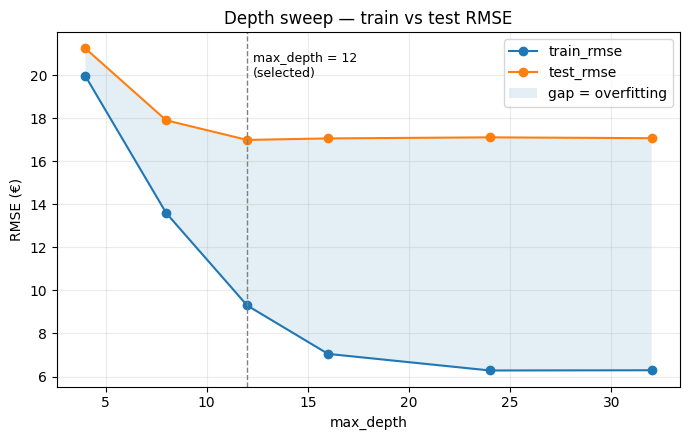

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(sweep["max_depth"], sweep["train_rmse"], marker="o", label="train_rmse")
ax.plot(sweep["max_depth"], sweep["test_rmse"], marker="o", label="test_rmse")

# The area between the curves is the overfitting gap.
ax.fill_between(sweep["max_depth"], sweep["train_rmse"], sweep["test_rmse"],
                alpha=0.12, label="gap = overfitting")

ax.axvline(12, linestyle="--", linewidth=1, color="grey")
ax.annotate("max_depth = 12\n(selected)", xy=(12, ax.get_ylim()[1]),
            xytext=(4, -14), textcoords="offset points", fontsize=9, va="top")

ax.set_xlabel("max_depth")
ax.set_ylabel("RMSE (€)")
ax.set_title("Depth sweep — train vs test RMSE")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

`train_rmse` collapses as depth increases while `test_rmse` flattens out; the area between them widens throughout.

The comparison with the linear regression from the `getaround-pricing` experiment is worth making:

| | train RMSE | test RMSE | gap |
|---|---|---|---|
| Random forest (`depth=12`) | ≈ 9.3 | ≈ 17.0 | **+7.7** |
| Linear regression | ≈ 17.8 | ≈ 18.4 | **+0.55** |

The forest overfits and the linear model does not — it is too constrained to memorise anything, which is bias rather than virtue. What decides the choice is test performance: the forest's overfitting is an acceptable price for better generalisation.

---

## Completing the demonstration

This notebook is view 1. The other two:

- **view 2** — the Neon console, where the step 2 query returns the same runs from a browser that touches nothing on this machine;
- **view 3** — `mlflow ui --backend-store-uri "$MLFLOW_TRACKING_URI"`, showing the same runs on `localhost:5000`.

Three tools with nothing in common, one source of truth. The tracking data does not live on this machine; it lives in the database.